In [3]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
%matplotlib inline
import matplotlib as mpl
mpl.rcParams['animation.embed_limit'] = 70.0

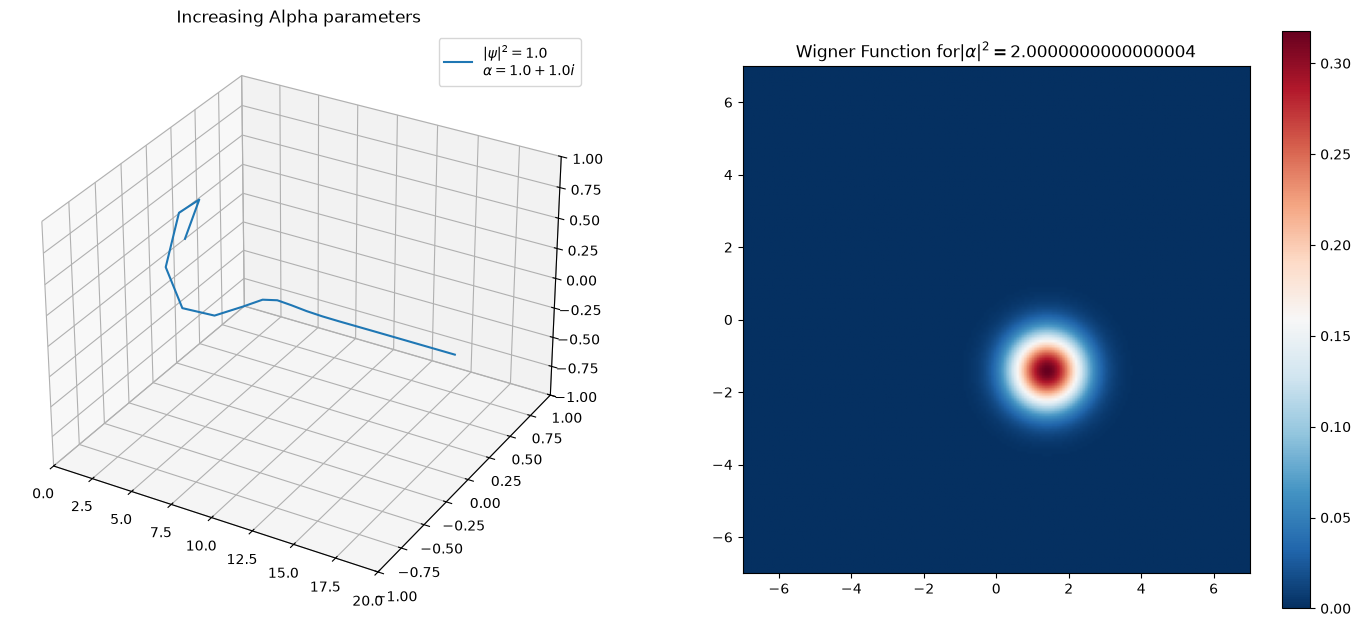

In [ ]:
N = 20
alpha = 1 + 1j
maxtime = 6
tlist=np.linspace(1,maxtime,100)
vaccum = qt.basis(N,0)
numlist=np.linspace(0,N-1,N)



def seperate(states):
    real= np.real(states.full().flatten())
    imag = np.imag(states.full().flatten())
    return real,imag

def coherentState(t,N=N,alpha = alpha):
    return qt.coherent(N, alpha=alpha*t)

x=np.linspace(-7,7,200)
p=np.linspace(-7,7,200)
X,Y = np.meshgrid(x,p)


fig = plt.figure(figsize=(18,7.5),dpi=100)
ax = fig.add_subplot(1,2,1,projection="3d",)
ax2 = fig.add_subplot(1,2,2)

y0, z0=seperate(coherentState(t=1))
line, = ax.plot(xs=numlist,zs=z0,ys=y0,label=f"$|\\psi|^2={round(np.sum(y0**2+z0**2),2)}$"+"\n"+f"$\\alpha = {round(alpha.real,2)}+{round(alpha.imag,2)}i$")
heat = ax2.imshow(qt.wigner(coherentState(t=1),xvec=x,yvec=p),cmap='RdBu_r',extent=[-7,7,-7,7]) #type:ignore
ax2.set_title("Wigner Function for"+f" $|\\alpha|^2 ={abs(alpha)**2}$")


ax.set_title("Increasing Alpha parameters")

def update(frame):
    t=tlist[frame]
    alphaState=coherentState(t=t)
    yt,zt=seperate(alphaState)
    alphaT=alpha*t
    line.set_data(numlist,yt)
    line.set_3d_properties(zt)
    heat.set_data((qt.wigner(coherentState(t=t),xvec=x,yvec=p))) #type:ignore
    line.set_label(f"$|\\psi|^2={round(np.sum(yt**2+zt**2),2)}$"+"\n"+f"$\\alpha = {round((alphaT).real,2)}+{round((alphaT).imag,2)}i$") #type:ignore
    ax.legend(loc="upper right")
    ax2.set_title("Wigner Function for"+f" $|\\alpha|^2 ={abs(alpha*t)**2}$")
    return line

anim= FuncAnimation(fig,update,frames=len(tlist),interval = 50)



ax.set_xlim(0,N)
ax.set_ylim(-1,1)
ax.set_zlim(-1,1)
ax.legend()
fig.colorbar(heat,ax=ax2)
anim.save('Results\\wignerFunctionoTruncation.gif', writer='pillow', fps=25)



In [8]:
HTML('<img src="Results\\wignerFunctionoTruncation.gif">')